In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [2]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


## Load Cleaned & Merged Dataset

In [3]:
DATA_PATH = "../data/processed/all_merged.parquet"
df = pd.read_parquet(DATA_PATH)

print("Loaded dataframe shape:", df.shape)
df.dtypes.head()



Loaded dataframe shape: (8914963, 34)


transaction_id             int64
timestamp         datetime64[ns]
user_id                    int64
card_id                    int64
amount                   float64
dtype: object

In [ ]:
print("Shape:", df.shape)
print("\nNull ratio per column:")
display(df.isna().mean().sort_values(ascending=False).head(20))

print("\nUnique counts for key IDs:")
for col in ["transaction_id", "user_id", "card_id", "merchant_id"]:
    print(col, "→", df[col].nunique())
    
print("\nTimestamp range:")
print(df["timestamp"].min(), "→", df["timestamp"].max(


Shape: (8914963, 34)

Null ratio per column:


zip                     0.1242
merchant_state          0.1175
latitude                0.0000
card_on_dark_web        0.0000
current_age             0.0000
retirement_age          0.0000
birth_year              0.0000
birth_month             0.0000
gender                  0.0000
transaction_id          0.0000
acct_open_date          0.0000
longitude               0.0000
per_capita_income       0.0000
yearly_income           0.0000
total_debt              0.0000
credit_score            0.0000
num_credit_cards        0.0000
year_pin_last_changed   0.0000
credit_limit            0.0000
timestamp               0.0000
dtype: float64


Unique counts for key IDs:
transaction_id → 8914963
user_id → 1219
card_id → 4070
merchant_id → 66537

Timestamp range:
2010-01-01 00:01:00 → 2019-10-31 23:57:00


## 🎯 EDA Goals – Fraud Detection System

This focused EDA answers key questions that influence fraud modeling:

- What is the fraud rate? (class imbalance)
- How do fraud patterns differ by amount, time, merchant category, and geography?
- How do card risk signals (chip usage, dark web, limit utilization) correlate with fraud?
- What customer features are associated with higher fraud risk?
- Which MCC categories show elevated fraud rates?

These insights guide feature engineering, model design, thresholds, and business rules.


### Check Basic Info & Missingness

In [5]:
print("Shape:", df.shape)
print("\nMissing values (%):")
display(df.isna().mean().sort_values(ascending=False).head(20))


Shape: (8914963, 34)

Missing values (%):


zip                     0.1242
merchant_state          0.1175
latitude                0.0000
card_on_dark_web        0.0000
current_age             0.0000
retirement_age          0.0000
birth_year              0.0000
birth_month             0.0000
gender                  0.0000
transaction_id          0.0000
acct_open_date          0.0000
longitude               0.0000
per_capita_income       0.0000
yearly_income           0.0000
total_debt              0.0000
credit_score            0.0000
num_credit_cards        0.0000
year_pin_last_changed   0.0000
credit_limit            0.0000
timestamp               0.0000
dtype: float64

### Target Distribution (Fraud Rate)

In [6]:
print("Fraud counts:")
print(df["target"].value_counts())

print("\nFraud rate (%):")
print(df["target"].value_counts(normalize=True) * 100)


Fraud counts:
target
0    8901631
1      13332
Name: count, dtype: int64

Fraud rate (%):
target
0   99.8505
1    0.1495
Name: proportion, dtype: float64


Label / fraud rate

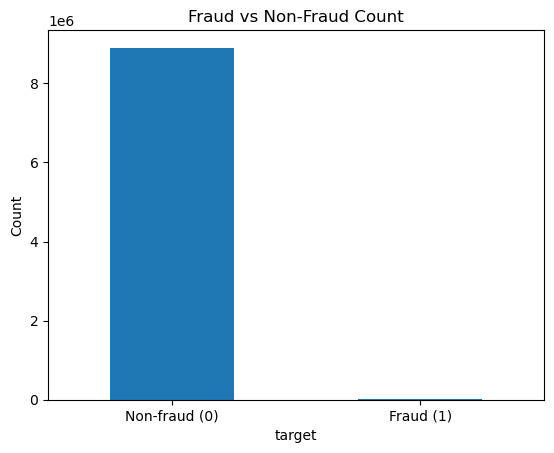

In [7]:
# Bar chart of counts or percentages.
target_counts = df["target"].value_counts().sort_index()
target_counts.plot(kind="bar")
plt.title("Fraud vs Non-Fraud Count")
plt.xticks([0, 1], ["Non-fraud (0)", "Fraud (1)"], rotation=0)
plt.ylabel("Count")
plt.show()
# fraud is rare but costly

## 2: Amount Analysis (Fraud vs Legit)
Build Small EDA Sample

In [8]:
##
fraud_df = df[df["target"] == 1]
legit_df = df[df["target"] == 0].sample(n=300_000, random_state=42)

eda_sample = pd.concat([fraud_df, legit_df]).reset_index(drop=True)
eda_sample.shape


(313332, 34)

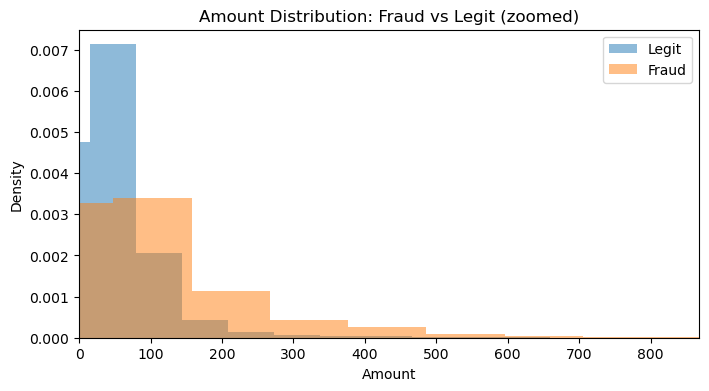

In [9]:
plt.figure(figsize=(8,4))
plt.hist(legit_df["amount"], bins=50, alpha=0.5, label="Legit", density=True)
plt.hist(fraud_df["amount"], bins=50, alpha=0.5, label="Fraud", density=True)
plt.xlim(0, fraud_df["amount"].quantile(0.99))  # zoom in
plt.legend()
plt.title("Amount Distribution: Fraud vs Legit (zoomed)")
plt.xlabel("Amount")
plt.ylabel("Density")
plt.show()

# Frauds tend to concentrate at X–Y range compared to legit.

Amount Statistics

In [10]:
fraud_amount = fraud_df["amount"]
legit_amount = legit_df["amount"]

print("Fraud Amount Stats:\n", fraud_amount.describe())
print("\nLegit Amount Stats:\n", legit_amount.describe())


Fraud Amount Stats:
 count   13,332.0000
mean       110.2347
std        213.7362
min       -500.0000
25%         17.8350
50%         69.9750
75%        148.4925
max      4,978.4500
Name: amount, dtype: float64

Legit Amount Stats:
 count   300,000.0000
mean         42.8069
std          81.1143
min        -500.0000
25%           8.9500
50%          29.0100
75%          63.5700
max       2,721.9600
Name: amount, dtype: float64


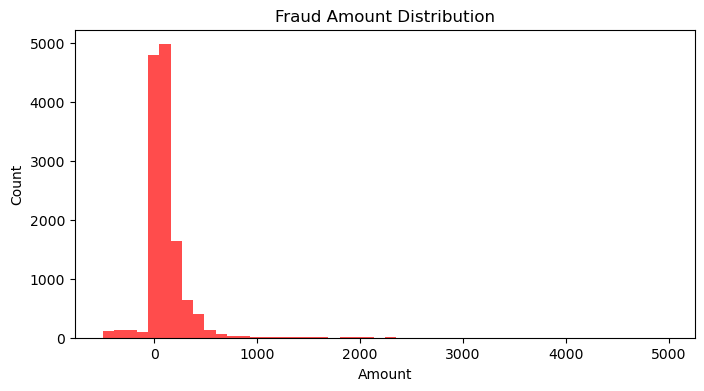

In [11]:
plt.figure(figsize=(8,4))
plt.hist(fraud_amount, bins=50, alpha=0.7, color='red')
plt.title("Fraud Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Count")
plt.show()


## 3: Time-Based Fraud Patterns
Extract Hour & Day-of-Week

In [12]:
df["hour"] = df["timestamp"].dt.hour
df["dayofweek"] = df["timestamp"].dt.dayofweek  # 0=Mon


Fraud Rate by Hour / Day

In [13]:
hour_fraud = df.groupby("hour")["target"].mean()
day_fraud = df.groupby("dayofweek")["target"].mean()

print("Fraud Rate by Hour:\n", hour_fraud)
print("\nFraud Rate by Day of Week:\n", day_fraud)


Fraud Rate by Hour:
 hour
0    0.0001
1    0.0005
2    0.0005
3    0.0015
4    0.0019
5    0.0020
6    0.0009
7    0.0009
8    0.0009
9    0.0015
10   0.0026
11   0.0025
12   0.0022
13   0.0022
14   0.0018
15   0.0017
16   0.0015
17   0.0016
18   0.0016
19   0.0014
20   0.0001
21   0.0002
22   0.0000
23   0.0002
Name: target, dtype: float64

Fraud Rate by Day of Week:
 dayofweek
0   0.0014
1   0.0016
2   0.0009
3   0.0016
4   0.0018
5   0.0011
6   0.0021
Name: target, dtype: float64


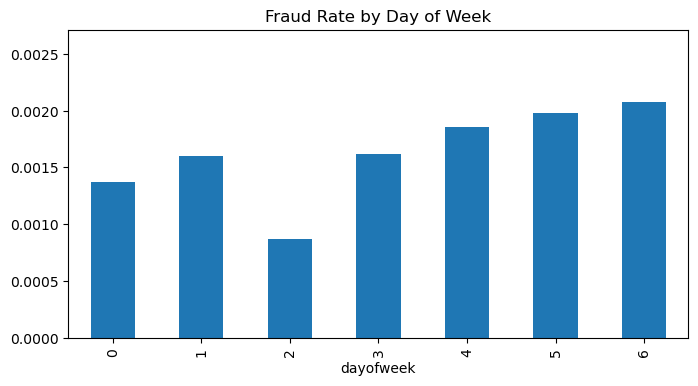

In [14]:
hour_fraud.plot(kind="bar", title="Fraud Rate by Hour", figsize=(8,4));
day_fraud.plot(kind="bar", title="Fraud Rate by Day of Week", figsize=(8,4));


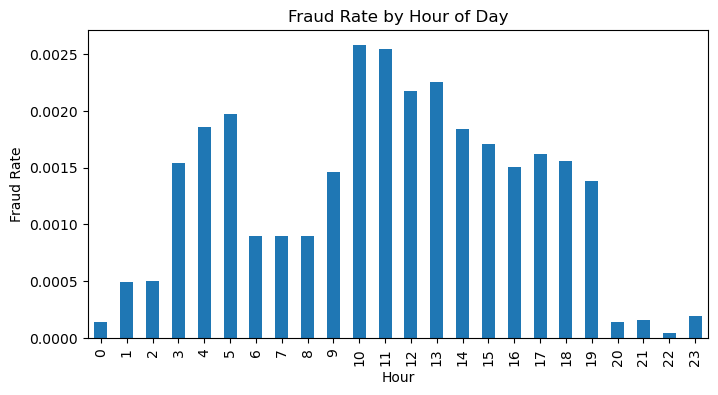

In [15]:
plt.figure(figsize=(8,4))
hour_fraud.plot(kind="bar")
plt.title("Fraud Rate by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")
plt.show()

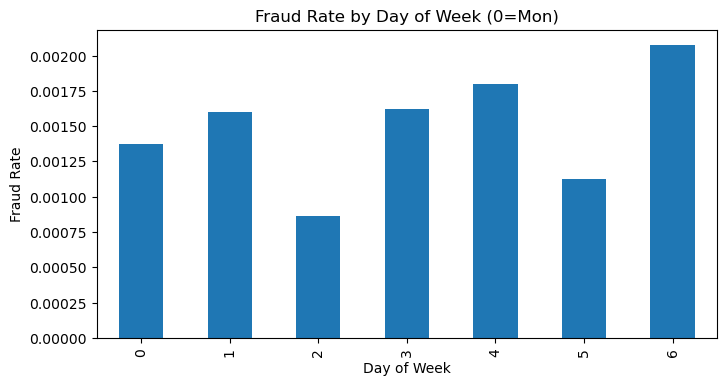

In [16]:
plt.figure(figsize=(8,4))
day_fraud.plot(kind="bar")
plt.title("Fraud Rate by Day of Week (0=Mon)")
plt.xlabel("Day of Week")
plt.ylabel("Fraud Rate")
plt.show()

# “fraud spikes at late night”

## 4: Card Risk Signals
Fraud Rate by Chip Usage & Dark Web Flags

In [17]:
print("Fraud by use_chip:")
print(df.groupby("use_chip")["target"].mean())

print("\nFraud by has_chip:")
print(df.groupby("has_chip")["target"].mean())

print("\nFraud by card_on_dark_web:")
print(df.groupby("card_on_dark_web")["target"].mean())


Fraud by use_chip:
use_chip
Chip Transaction     0.0010
Online Transaction   0.0084
Swipe Transaction    0.0003
Name: target, dtype: float64

Fraud by has_chip:
has_chip
NO    0.0013
YES   0.0015
Name: target, dtype: float64

Fraud by card_on_dark_web:
card_on_dark_web
No   0.0015
Name: target, dtype: float64


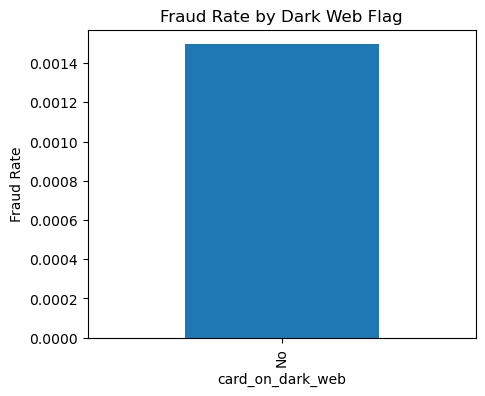

In [18]:
card_dark = df.groupby("card_on_dark_web")["target"].mean()

plt.figure(figsize=(5,4))
card_dark.plot(kind="bar")
plt.title("Fraud Rate by Dark Web Flag")
plt.xlabel("card_on_dark_web")
plt.ylabel("Fraud Rate")
plt.show()

# small bar charts for use_chip and has_chip
# These are gold in a presentation:
# “Cards known to be on the dark web show X× higher fraud rate.


Card Limit Utilization

In [19]:
df["utilization"] = df["amount"] / df["credit_limit"]

print(df["utilization"].describe())

print("\nFraud Rate by Utilization Buckets:")
print(df.groupby(pd.qcut(df["utilization"].replace([np.inf, -np.inf], np.nan)
                         .fillna(0), 5))["target"].mean())


count   8,914,844.0000
mean               NaN
std                NaN
min               -inf
25%             0.0007
50%             0.0024
75%             0.0066
max                inf
Name: utilization, dtype: float64

Fraud Rate by Utilization Buckets:
utilization
(-33.001, 0.000427]   0.0011
(0.000427, 0.0015]    0.0007
(0.0015, 0.00353]     0.0010
(0.00353, 0.00838]    0.0015
(0.00838, 322.62]     0.0031
Name: target, dtype: float64


## 5: Customer-Level Signals
Fraud vs Credit Score

In [20]:
credit_bins = pd.qcut(df["credit_score"], q=5, duplicates="drop")
credit_fraud=df.groupby(credit_bins)["target"].mean()


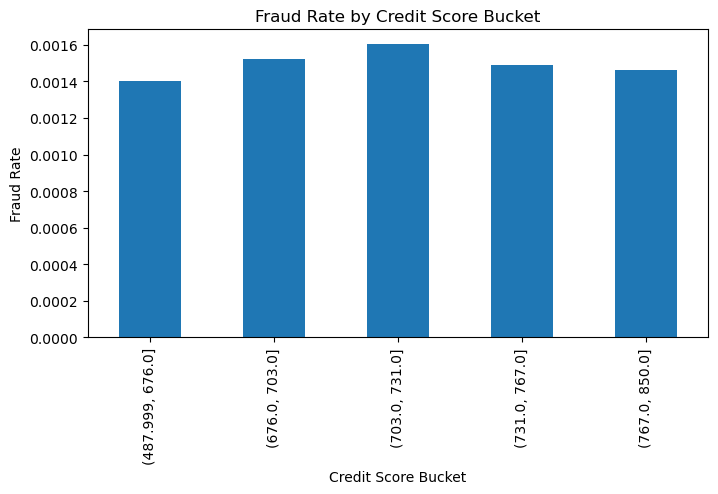

In [21]:
plt.figure(figsize=(8,4))
credit_fraud.plot(kind="bar")
plt.title("Fraud Rate by Credit Score Bucket")
plt.xlabel("Credit Score Bucket")
plt.ylabel("Fraud Rate")
plt.show()

Fraud vs Age

In [22]:
age_bins = pd.qcut(df["current_age"], q=4, duplicates="drop")
df.groupby(age_bins)["target"].mean()


current_age
(22.999, 42.0]   0.0013
(42.0, 52.0]     0.0014
(52.0, 63.0]     0.0016
(63.0, 101.0]    0.0017
Name: target, dtype: float64

## 6: Merchant/MCC Risk
MCC Fraud Rates

In [23]:
mcc_stats = (
    df.groupby("mcc_description")["target"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

mcc_stats.head(20)


,mean,count
mcc_description,,
Cruise Lines,0.5978,276
Music Stores - Musical Instruments,0.3725,204
Miscellaneous Fabricated Metal Products,0.1184,245
"Computers, Computer Peripheral Equipment",0.1083,1883
Floor Covering Stores,0.1036,222
Miscellaneous Metal Fabrication,0.0859,256
Electronics Stores,0.0857,4689
Fabricated Structural Metal Products,0.0806,273
Precious Stones and Metals,0.0687,3525


Filter MCCs with Enough Volume

In [24]:
mcc_filtered = mcc_stats[mcc_stats["count"] > 1000]
mcc_filtered.sort_values("mean", ascending=False).head(20)


,mean,count
mcc_description,,
"Computers, Computer Peripheral Equipment",0.1083,1883
Electronics Stores,0.0857,4689
Precious Stones and Metals,0.0687,3525
"Furniture, Home Furnishings, and Equipment Stores",0.0654,2600
Digital Goods - Games,0.0584,1866
Bus Lines,0.0299,1506
Antique Shops,0.0216,3977
Passenger Railways,0.0200,11877
Airlines,0.0199,1913


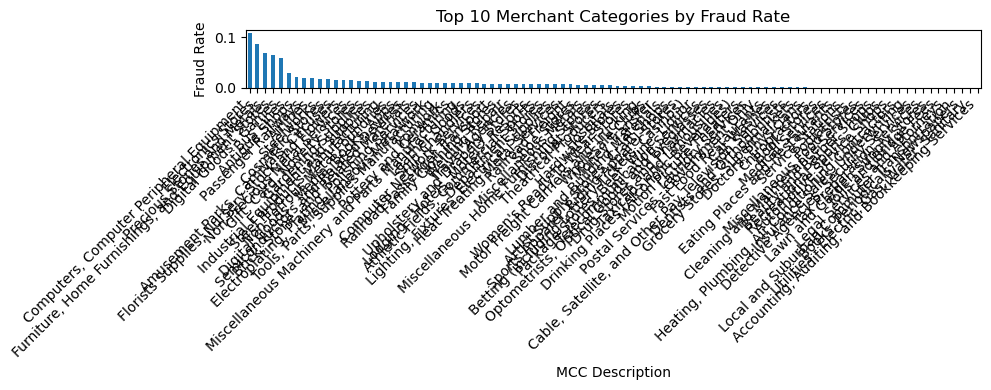

In [25]:
plt.figure(figsize=(10,4))
mcc_filtered["mean"].plot(kind="bar")
plt.title("Top 10 Merchant Categories by Fraud Rate")
plt.ylabel("Fraud Rate")
plt.xlabel("MCC Description")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 7: Geography
Merchant State Fraud Rate

In [26]:
state_fraud = (
    df.groupby("merchant_state")["target"]
      .agg(["mean", "count"])
      .sort_values("mean", ascending=False)
)

state_fraud.head(20)


,mean,count
merchant_state,,
Tuvalu,1.0000,5
Haiti,0.9583,264
Italy,0.6504,4706
OH,0.0010,324098
SD,0.0004,20875
IA,0.0003,107765
MO,0.0002,131274
NJ,0.0002,216075
WY,0.0002,5874


## 8: Feature Quality Checks
High Cardinality

In [27]:
for col in ["merchant_city", "merchant_state", "merchant_id", "mcc_description"]:
    print(col, "unique:", df[col].nunique())


merchant_city unique: 12173
merchant_state unique: 199
merchant_id unique: 66537
mcc_description unique: 108


Invalid/Weird Value Checks

In [28]:
print("Negative amounts:", (df["amount"] < 0).sum())
print("Credit score describe:", df["credit_score"].describe())
print("Age describe:", df["current_age"].describe())


Negative amounts: 442779
Credit score describe: count   8,914,963.0000
mean          713.9262
std            65.8149
min           488.0000
25%           684.0000
50%           716.0000
75%           756.0000
max           850.0000
Name: credit_score, dtype: float64
Age describe: count   8,914,963.0000
mean           54.0215
std            15.7248
min            23.0000
25%            42.0000
50%            52.0000
75%            63.0000
max           101.0000
Name: current_age, dtype: float64
